# Task 4B: SEAL-Augmented LoRA — Steel Surface Defects

Image + Prompt → CoT Description + JSON

GPT-4.1 generates answer-conditioned reasoning for each training image.
Same 18 images as Direct, but 4 examples per image = 72 training pairs.
15 epochs, lr=1e-5.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import json, re, time, torch, gc, random, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

random.seed(SEED)
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Step 1: Select Training Images (same seed = same selection as Direct)

In [2]:
train_data = []
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_IMAGES_DIR, cls)
    all_imgs = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.png', '.bmp'))])
    selected = random.sample(all_imgs, IMAGES_PER_CLASS)
    for img_name in selected:
        train_data.append({'image': os.path.join(cls_dir, img_name), 'class': cls})
    print(f'{cls}: {selected}')
print(f'\nTotal: {len(train_data)} training images')

crazing: ['crazing_3.jpg', 'crazing_124.jpg', 'crazing_104.jpg']
inclusion: ['inclusion_53.jpg', 'inclusion_162.jpg', 'inclusion_155.jpg']
patches: ['patches_150.jpg', 'patches_130.jpg', 'patches_52.jpg']
pitted_surface: ['pitted_surface_122.jpg', 'pitted_surface_39.jpg', 'pitted_surface_53.jpg']
rolled-in_scale: ['rolled-in_scale_89.jpg', 'rolled-in_scale_224.jpg', 'rolled-in_scale_119.jpg']
scratches: ['scratches_235.jpg', 'scratches_197.jpg', 'scratches_106.jpg']

Total: 18 training images


## Step 2: Generate CoT Descriptions via GPT-4.1

In [5]:
from openai import AzureOpenAI

API_KEY = '871a30b46ebf4297a8938ff5fca23646'
client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=API_KEY, api_version=AZURE_API_VERSION)
print(f'GPT-4.1 client ready (key set: {bool(API_KEY)})')

GPT-4.1 client ready (key set: True)


In [6]:
def encode_image(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def generate_cot(image_path, defect_class):
    img_b64 = encode_image(image_path)
    resp = client.chat.completions.create(
        model=AZURE_DEPLOYMENT, temperature=0.7, max_completion_tokens=512,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{img_b64}'}},
            {'type': 'text', 'text': make_seal_prompt(defect_class)},
        ]}])
    return resp.choices[0].message.content.strip()

print('CoT generation ready.')

CoT generation ready.


In [7]:
COT_PER_IMAGE = 3
augmented_path = 'training_data_augmented.jsonl'
PROMPT = make_prompt()
# Remove the last 2 lines (empty line + 'Respond with ONLY JSON...' + JSON template) for description examples
PROMPT_NO_JSON = '\n'.join(PROMPT.split('\n')[:-2])

if os.path.exists(augmented_path):
    with open(augmented_path) as f:
        augmented_data = [json.loads(l) for l in f]
    print(f'Loaded existing: {len(augmented_data)} examples')
else:
    augmented_data = []
    for idx, entry in enumerate(train_data):
        cls = entry['class']
        img = entry['image']
        gt_json = json.dumps({'defect_class': cls})
        print(f'[{idx+1}/{len(train_data)}] {cls}: {os.path.basename(img)}')
        
        # 1 direct example (full prompt with JSON instruction)
        augmented_data.append({'messages': [
            {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]},
            {'role': 'assistant', 'content': gt_json},
        ]})
        
        # 3 CoT examples (prompt WITHOUT JSON line, response = description + JSON appended by us)
        for j in range(COT_PER_IMAGE):
            try:
                description = generate_cot(img, cls)
                # GPT-4.1 returns ONLY the description — we append the JSON ourselves
                cot_response = description.strip() + '\n' + gt_json
                augmented_data.append({'messages': [
                    {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT_NO_JSON}]},
                    {'role': 'assistant', 'content': cot_response},
                ]})
                print(f'  CoT {j+1}: {len(description)} chars')
            except Exception as e:
                print(f'  CoT {j+1}: ERROR — {e}')
            time.sleep(0.3)
    
    with open(augmented_path, 'w') as f:
        for ex in augmented_data: f.write(json.dumps(ex) + '\n')
    print(f'\nSaved {len(augmented_data)} examples ({len(train_data)} direct + {len(augmented_data)-len(train_data)} CoT)')

[1/18] crazing: crazing_3.jpg
  CoT 1: 491 chars
  CoT 2: 463 chars
  CoT 3: 483 chars
[2/18] crazing: crazing_124.jpg
  CoT 1: 509 chars
  CoT 2: 540 chars
  CoT 3: 490 chars
[3/18] crazing: crazing_104.jpg
  CoT 1: 469 chars
  CoT 2: 562 chars
  CoT 3: 479 chars
[4/18] inclusion: inclusion_53.jpg
  CoT 1: 536 chars
  CoT 2: 532 chars
  CoT 3: 528 chars
[5/18] inclusion: inclusion_162.jpg
  CoT 1: 488 chars
  CoT 2: 498 chars
  CoT 3: 468 chars
[6/18] inclusion: inclusion_155.jpg
  CoT 1: 511 chars
  CoT 2: 546 chars
  CoT 3: 574 chars
[7/18] patches: patches_150.jpg
  CoT 1: 522 chars
  CoT 2: 522 chars
  CoT 3: 474 chars
[8/18] patches: patches_130.jpg
  CoT 1: 577 chars
  CoT 2: 480 chars
  CoT 3: 576 chars
[9/18] patches: patches_52.jpg
  CoT 1: 435 chars
  CoT 2: 505 chars
  CoT 3: 528 chars
[10/18] pitted_surface: pitted_surface_122.jpg
  CoT 1: 460 chars
  CoT 2: 442 chars
  CoT 3: 500 chars
[11/18] pitted_surface: pitted_surface_39.jpg
  CoT 1: 446 chars
  CoT 2: 481 chars
  C

In [8]:
# Preview a CoT example
cot_ex = [ex for ex in augmented_data if len(ex['messages'][1]['content']) > 100]
if cot_ex:
    print('=== Sample CoT ===')
    print(cot_ex[0]['messages'][1]['content'][:500])

=== Sample CoT ===
The dominant visual pattern in this image is a network of fine, irregular lines forming a web-like or mosaic texture across the surface, with no single directionality. This matches the definition of crazing, as the cracks interconnect to create a netted appearance rather than isolated or sharply defined marks. It is not scratches, since there are no long, straight, sharply directional lines, and it is not inclusion or rolled-in scale, as there are no distinct spots or elongated streaks.
{"defect


## Step 3: Load Model + LoRA

In [9]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', dtype=torch.bfloat16,
    max_memory={0: '6GiB', 1: '15GiB'})
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')

print(f'Fresh model loaded (BF16).')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.22it/s]


Fresh model loaded (BF16).
  GPU 0: 3.7 GB
  GPU 1: 3.9 GB


## Step 4: Dataset + Training

In [10]:
class SteelDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        img_path = next((c['image'] for c in msgs[0]['content'] if c['type']=='image'), None)
        user_text = next((c['text'] for c in msgs[0]['content'] if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str): assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}

EPOCHS = 15
LR = 1e-5
GRAD_ACCUM = 4

def train_lora(base_model, data_path, output_dir, epochs=EPOCHS, lr=LR):
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = SteelDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, lr={lr}')
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    model.train()
    losses = []
    t_start = time.time()
    for epoch in range(epochs):
        epoch_loss = 0; n_ok = 0
        for i in range(len(dataset)):
            try:
                batch = dataset[i]
                ids = batch['input_ids'].unsqueeze(0).to(model.device)
                mask = batch['attention_mask'].unsqueeze(0).to(model.device)
                lab = batch['labels'].unsqueeze(0).to(model.device)
                kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
                if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
                if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
                out = model(**kw)
                loss = out.loss / GRAD_ACCUM
                loss.backward()
                epoch_loss += loss.item() * GRAD_ACCUM; n_ok += 1
                if (i+1) % GRAD_ACCUM == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step(); scheduler.step(); optimizer.zero_grad()
                del ids, mask, lab, out, loss; torch.cuda.empty_cache()
            except Exception as e:
                print(f'  Skip {i} (epoch {epoch+1}): {e}')
                optimizer.zero_grad(); torch.cuda.empty_cache()
        avg = epoch_loss / max(n_ok, 1)
        losses.append(avg)
        if (epoch+1) % 3 == 0 or epoch == 0:
            elapsed = time.time() - t_start
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e} — {elapsed:.0f}s')
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    plt.figure(figsize=(8,4))
    plt.plot(range(1,len(losses)+1), losses)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Training Loss ({output_dir})')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return model, losses

print('Training function ready.')

Training function ready.


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 72 examples, 15 epochs, lr=1e-05


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization i

  Epoch 1/15 — loss: 1.4758 — lr: 6.67e-06 — 141s
  Epoch 3/15 — loss: 1.2862 — lr: 9.70e-06 — 423s
  Epoch 6/15 — loss: 0.8923 — lr: 7.50e-06 — 844s
  Epoch 9/15 — loss: 0.7233 — lr: 4.13e-06 — 1266s
  Epoch 12/15 — loss: 0.6616 — lr: 1.17e-06 — 1689s
  Epoch 15/15 — loss: 0.6483 — lr: 0.00e+00 — 2109s
Adapter saved to lora_augmented/


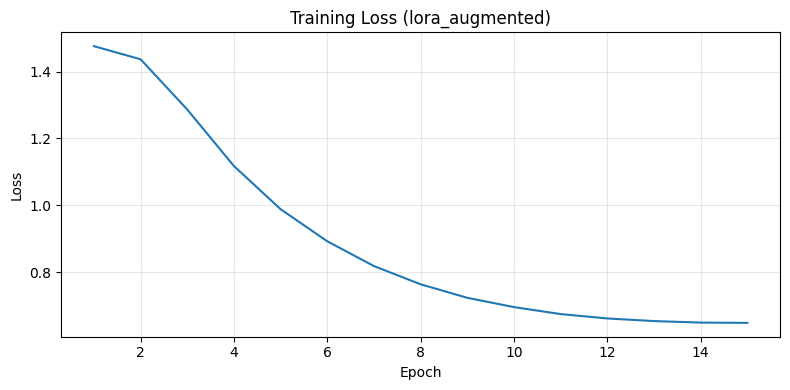

In [11]:
model, losses = train_lora(base_model, augmented_path, 'lora_augmented', epochs=EPOCHS, lr=LR)

In [16]:
# Continue training for 25 more epochs
EXTRA_EPOCHS = 25
LR_RESUME = 5e-6  # lower LR for continued training

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_RESUME, weight_decay=0.01)
total_steps = max(len(augmented_data) * EXTRA_EPOCHS // GRAD_ACCUM, 1)
scheduler = get_cosine_schedule_with_warmup(optimizer, 0, total_steps)

dataset = SteelDataset(augmented_path, processor)
model.train()
t_start = time.time()

for epoch in range(EXTRA_EPOCHS):
    epoch_loss = 0; n_ok = 0
    for i in range(len(dataset)):
        try:
            batch = dataset[i]
            ids = batch['input_ids'].unsqueeze(0).to(model.device)
            mask = batch['attention_mask'].unsqueeze(0).to(model.device)
            lab = batch['labels'].unsqueeze(0).to(model.device)
            kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
            if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
            if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
            out = model(**kw)
            loss = out.loss / GRAD_ACCUM
            loss.backward()
            epoch_loss += loss.item() * GRAD_ACCUM; n_ok += 1
            if (i+1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            del ids, mask, lab, out, loss; torch.cuda.empty_cache()
        except Exception as e:
            print(f'  Skip {i} (epoch {epoch+1}): {e}')
            optimizer.zero_grad(); torch.cuda.empty_cache()
    avg = epoch_loss / max(n_ok, 1)
    losses.append(avg)
    if (epoch+1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - t_start
        print(f'  Epoch {15+epoch+1}/40 — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e} — {elapsed:.0f}s')

model.save_pretrained('lora_augmented')
print(f'Adapter re-saved to lora_augmented/ (40 total epochs)')

  Epoch 16/40 — loss: 0.6500 — lr: 4.98e-06 — 140s
  Epoch 20/40 — loss: 0.5501 — lr: 4.52e-06 — 702s
  Epoch 25/40 — loss: 0.4685 — lr: 3.27e-06 — 1405s
  Epoch 30/40 — loss: 0.4192 — lr: 1.73e-06 — 2106s
  Epoch 35/40 — loss: 0.3980 — lr: 4.77e-07 — 2805s
  Epoch 40/40 — loss: 0.3941 — lr: 0.00e+00 — 3505s
Adapter re-saved to lora_augmented/ (40 total epochs)


## Step 5: Evaluate on 360 Test Images

In [17]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w-]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):
        if cls in raw_lower: return {'defect_class': cls}
    return None

def evaluate(model, processor, test_dir, classes, prompt):
    model.eval()
    results = []; correct = 0; valid = 0; total_time = 0
    manifest = []
    for cls in classes:
        cls_dir = os.path.join(test_dir, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.png', '.bmp')):
                manifest.append({'image': os.path.join(cls_dir, f), 'class': cls})
    print(f'Evaluating on {len(manifest)} images...')
    for i, entry in enumerate(manifest):
        image = Image.open(entry['image']).convert('RGB')
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t = time.time()
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=True)
        elapsed = time.time() - t; total_time += elapsed
        out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        parsed = parse_response(out)
        gt = entry['class']; ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'predicted': parsed,
            'raw': out, 'correct': ok, 'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        if (i+1) % 60 == 0:
            n = i+1; print(f'  [{n}/{len(manifest)}] Acc: {correct}/{n} ({correct/n*100:.0f}%)')
    return results, correct, valid, total_time

print('Eval functions ready.')

Eval functions ready.


In [18]:
PROMPT = make_prompt()
results, correct, valid, eval_time = evaluate(model, processor, TEST_IMAGES_DIR, CLASSES, PROMPT)
n = len(results)
print(f'\nSEAL LoRA: {correct}/{n} ({correct/n*100:.1f}%) | JSON: {valid}/{n} | {eval_time/n:.1f}s/img')

# Per-class
print(f'\nPer-class:')
by_class = defaultdict(list)
for r in results: by_class[r['class']].append(r)
for cls in CLASSES:
    cr = by_class[cls]; c = sum(1 for r in cr if r['correct'])
    print(f'  {cls:<22} {c:>3}/{len(cr)} ({c/len(cr)*100:.0f}%)')

Evaluating on 360 images...
  [60/360] Acc: 47/60 (78%)
  [120/360] Acc: 59/120 (49%)
  [180/360] Acc: 102/180 (57%)
  [240/360] Acc: 129/240 (54%)
  [300/360] Acc: 148/300 (49%)
  [360/360] Acc: 175/360 (49%)

SEAL LoRA: 175/360 (48.6%) | JSON: 360/360 | 2.2s/img

Per-class:
  crazing                 47/60 (78%)
  inclusion               12/60 (20%)
  patches                 43/60 (72%)
  pitted_surface          27/60 (45%)
  rolled-in_scale         19/60 (32%)
  scratches               27/60 (45%)


In [19]:
with open('results_augmented.json', 'w') as f:
    json.dump({'model': MODEL_ID, 'method': 'seal_augmented_lora', 'dataset': 'NEU-CLS',
        'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
        'json_validity_pct': round(valid/n*100, 1), 'avg_inference_time_s': round(eval_time/n, 2),
        'training_images': 18, 'training_examples': len(augmented_data),
        'epochs': EPOCHS, 'lr': LR, 'results': results}, f, indent=2)
print('Saved results_augmented.json')

Saved results_augmented.json


## Comparison

In [20]:
print(f'{"Method":<30} {"Accuracy":>10}')
print('=' * 42)
print(f'{"Qwen base (ZS)":<30} {"21.7%":>10}')
print(f'{"Qwen base (FS)":<30} {"22.8%":>10}')
if os.path.exists('results_direct.json'):
    with open('results_direct.json') as f: d = json.load(f)
    print(f'{"Direct LoRA (18 imgs)":<30} {d["accuracy_pct"]:>9.1f}%')
print(f'{"SEAL LoRA (18 imgs, 72 ex)":<30} {correct/n*100:>9.1f}%')
print(f'{"GPT-4.1 FS (teacher)":<30} {"91.1%":>10}')
print(f'{"Random chance":<30} {"16.7%":>10}')

Method                           Accuracy
Qwen base (ZS)                      21.7%
Qwen base (FS)                      22.8%
Direct LoRA (18 imgs)               54.4%
SEAL LoRA (18 imgs, 72 ex)          48.6%
GPT-4.1 FS (teacher)                91.1%
Random chance                       16.7%
